# Contact thresholds & bond types across all region pairs

For a TCR-pMHC complex we count inter-chain residue contacts under three definitions and
break them down by **bond type** for **every** region pair (not just the MHC interface):

* **closest** — closest heavy-atom pair ≤ 5 Å (the original TCRen definition; the only kind that
  carries a bond classification),
* **cβ** — Cβ representative atom ≤ 8 Å (Cα fallback for Gly),
* **cα** — Cα representative atom ≤ 12 Å.

Bond types come from `tcren.project2d.classify_contact` (a documented heavy-atom heuristic:
salt bridge, hydrogen bond, aromatic, hydrophobic, polar). We also cross-check hydrogen bonds
with the external tool **biotite** (`biotite.structure.hbond`, Baker-Hubbard) and note its
explicit-hydrogen requirement. Structures are read only from the bootstrapped HF set.

In [1]:
# Imports + environment versions (reproducibility).
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, polars as pl, matplotlib, matplotlib.pyplot as plt
import biotite
import tcren
from tcren.structure.io import import_structure
from tcren.annotation import classify_chains
from tcren.mhc import annotate_mhc
from tcren.project2d import region_pair_summary, region_pair_contacts
for m in (tcren, pl, np, matplotlib, biotite):
    print(m.__name__, getattr(m, '__version__', '?'))
STRUCT = Path('data/Native2026')  # bootstrapped HF structures (gitignored)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True})

tcren 0.1.0
polars 1.41.2
numpy 2.4.6
matplotlib 3.11.0
biotite 1.6.0


In [2]:
# Load one representative class-I complex (1ao7: A6 TCR / HLA-A2 / Tax) and annotate it.
s = import_structure(STRUCT / '1ao7.pdb.gz', pdb_id='1ao7')
classify_chains(s, organism='human'); annotate_mhc(s)
print([(c.chain_id, c.chain_type) for c in s.chains])

[('A', 'TRA'), ('B', 'TRB'), ('C', 'PEPTIDE'), ('D', 'MHCa'), ('E', 'B2M')]


## 1. Region-pair contact counts under the three thresholds

In [3]:
# Per region-pair contact counts for each contact definition, joined side by side.
keys = ['complex_chain_1', 'region_1', 'complex_chain_2', 'region_2']
tbl = None
for kind in ('closest', 'cb', 'ca'):
    c = region_pair_summary(s, kind=kind).select(keys + ['n_contacts']).rename({'n_contacts': f'n_{kind}'})
    tbl = c if tbl is None else tbl.join(c, on=keys, how='full', coalesce=True)
tbl = tbl.fill_null(0).sort('n_closest', descending=True)
print('totals  closest=%d  cb=%d  ca=%d' % tuple(int(tbl[f'n_{k}'].sum()) for k in ('closest','cb','ca')))
tbl.head(15)

totals  closest=182  cb=213  ca=1213


complex_chain_1,region_1,complex_chain_2,region_2,n_closest,n_cb,n_ca
str,str,str,str,u32,u32,u32
"""mhca""","""mhc_helix_a1""","""peptide""","""peptide""",23,19,94
"""mhca""","""mhc_helix_a2""","""peptide""","""peptide""",20,18,90
"""tra""","""cdr3""","""trb""","""cdr3""",13,13,64
"""peptide""","""peptide""","""trb""","""cdr3""",13,10,42
"""mhca""","""groove_floor""","""peptide""","""peptide""",12,6,58
…,…,…,…,…,…,…
"""peptide""","""peptide""","""tra""","""cdr1""",7,2,17
"""mhca""","""mhc_helix_a2""","""tra""","""cdr2""",5,7,35
"""mhca""","""mhc_helix_a2""","""tra""","""cdr1""",5,4,27


shape: (5, 4)
┌───────────────────┬─────────┬─────┬─────┐
│ category          ┆ closest ┆ cb  ┆ ca  │
│ ---               ┆ ---     ┆ --- ┆ --- │
│ str               ┆ u32     ┆ u32 ┆ u32 │
╞═══════════════════╪═════════╪═════╪═════╡
│ intra-TCR (Vα–Vβ) ┆ 57      ┆ 45  ┆ 273 │
│ peptide–MHC       ┆ 55      ┆ 43  ┆ 242 │
│ TCR–MHC           ┆ 41      ┆ 47  ┆ 242 │
│ TCR–peptide       ┆ 29      ┆ 19  ┆ 90  │
│ other             ┆ 0       ┆ 59  ┆ 366 │
└───────────────────┴─────────┴─────┴─────┘


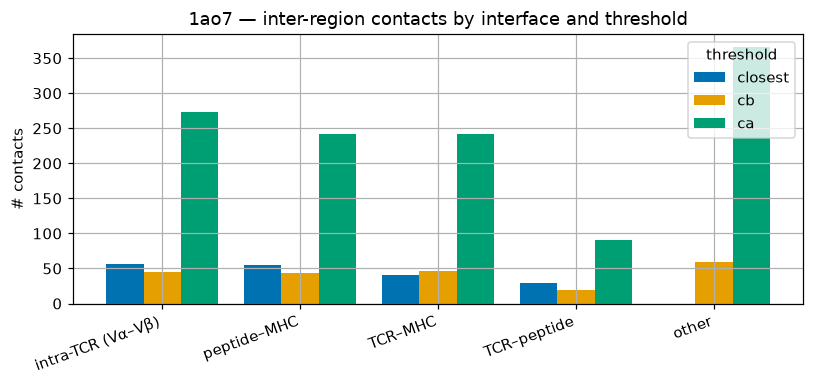

In [4]:
# Group region pairs into interface categories and compare contact counts across thresholds.
TCR = {'tra', 'trb', 'trd', 'trg'}
def category(r):
    cc = {r['complex_chain_1'], r['complex_chain_2']}
    if cc & TCR and 'peptide' in cc: return 'TCR–peptide'
    if cc & TCR and ('mhca' in cc or 'mhcb' in cc): return 'TCR–MHC'
    if 'peptide' in cc and ('mhca' in cc or 'mhcb' in cc): return 'peptide–MHC'
    if cc <= TCR: return 'intra-TCR (Vα–Vβ)'
    return 'other'
cat = tbl.with_columns(pl.struct(keys).map_elements(category, return_dtype=pl.Utf8).alias('category'))
agg = cat.group_by('category').agg([pl.col(f'n_{k}').sum().alias(k) for k in ('closest','cb','ca')]).sort('closest', descending=True)
print(agg)
order = agg['category'].to_list(); x = np.arange(len(order)); w = 0.27
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for i, (k, col) in enumerate(zip(('closest','cb','ca'), ['#0072B2', '#E69F00', '#009E73'])):
    ax.bar(x + (i-1)*w, agg[k].to_list(), w, label=f'{k}', color=col)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=20, ha='right'); ax.set_ylabel('# contacts'); ax.legend(title='threshold')
ax.set_title('1ao7 — inter-region contacts by interface and threshold'); plt.tight_layout(); plt.show()

## 2. Bond types across all region pairs (closest-atom, 5 Å)

shape: (4, 7)
┌───────────────────┬───────────────┬─────────────┬──────────┬─────────────┬───────┬───────┐
│ category          ┆ hydrogen_bond ┆ salt_bridge ┆ aromatic ┆ hydrophobic ┆ polar ┆ other │
│ ---               ┆ ---           ┆ ---         ┆ ---      ┆ ---         ┆ ---   ┆ ---   │
│ str               ┆ u32           ┆ u32         ┆ u32      ┆ u32         ┆ u32   ┆ u32   │
╞═══════════════════╪═══════════════╪═════════════╪══════════╪═════════════╪═══════╪═══════╡
│ TCR–MHC           ┆ 8             ┆ 2           ┆ 0        ┆ 9           ┆ 22    ┆ 0     │
│ TCR–peptide       ┆ 8             ┆ 0           ┆ 0        ┆ 5           ┆ 16    ┆ 0     │
│ intra-TCR (Vα–Vβ) ┆ 7             ┆ 0           ┆ 3        ┆ 14          ┆ 33    ┆ 0     │
│ peptide–MHC       ┆ 10            ┆ 0           ┆ 1        ┆ 18          ┆ 26    ┆ 0     │
└───────────────────┴───────────────┴─────────────┴──────────┴─────────────┴───────┴───────┘


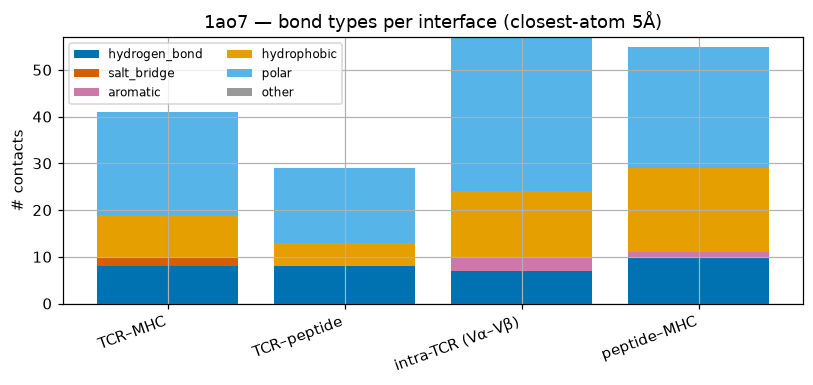

In [5]:
# Bond-type breakdown per region pair, then summed per interface category (stacked bar).
bt = region_pair_summary(s, kind='closest')
types = ['hydrogen_bond', 'salt_bridge', 'aromatic', 'hydrophobic', 'polar', 'other']
btc = bt.with_columns(pl.struct(keys).map_elements(category, return_dtype=pl.Utf8).alias('category'))
bagg = btc.group_by('category').agg([pl.col(f'n_{t}').sum().alias(t) for t in types]).sort('category')
print(bagg)
cats = bagg['category'].to_list(); bottom = np.zeros(len(cats))
palette = ['#0072B2', '#D55E00', '#CC79A7', '#E69F00', '#56B4E9', '#999999']
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for t, col in zip(types, palette):
    vals = np.array(bagg[t].to_list()); ax.bar(cats, vals, bottom=bottom, label=t, color=col); bottom += vals
ax.set_ylabel('# contacts'); ax.legend(ncol=2, fontsize=8); ax.set_title('1ao7 — bond types per interface (closest-atom 5Å)')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

## 3. External cross-check: biotite hydrogen bonds

`biotite.structure.hbond` is the Baker-Hubbard detector. It needs **explicit hydrogen atoms**
(D–H···A geometry). X-ray crystal structures have none, so it returns 0 here — which is why the
heavy-atom heuristic above is the operative method. biotite is the right tool for protonated /
NMR / MD-relaxed structures (or after adding H with `reduce`/`pdbfixer`).

In [6]:
# biotite Baker-Hubbard H-bonds vs our heuristic H-bond count.
import gzip, biotite.structure.io.pdb as biopdb, biotite.structure as struc
arr = biopdb.PDBFile.read(gzip.open(str(STRUCT / '1ao7.pdb.gz'), 'rt')).get_structure(model=1)
nH = int((arr.element == 'H').sum())
print(f'explicit H atoms in 1ao7: {nH}  ->  biotite.hbond triplets: {len(struc.hbond(arr))}')
print('heuristic inter-region hydrogen_bond contacts:', int(bt['n_hydrogen_bond'].sum()))

explicit H atoms in 1ao7: 0  ->  biotite.hbond triplets: 0
heuristic inter-region hydrogen_bond contacts: 33


## 4. Aggregate across a Native2026 sample

In [7]:
# Closest-atom contacts + H-bonds per interface category over a deterministic 15-structure sample.
files = sorted(STRUCT.glob('*.pdb.gz'))[:15]
frames = []
for fp in files:
    try:
        st = import_structure(fp, pdb_id=fp.stem[:4]); classify_chains(st, organism='human'); annotate_mhc(st)
        d = region_pair_summary(st, kind='closest')
        if d.height:
            frames.append(d.with_columns(pl.struct(keys).map_elements(category, return_dtype=pl.Utf8).alias('category')))
    except Exception as e:
        print('skip', fp.stem, type(e).__name__)
allc = pl.concat(frames)
summary = (allc.group_by('category')
           .agg([pl.col('n_contacts').sum().alias('total_contacts'), pl.col('n_hydrogen_bond').sum().alias('total_hbonds')])
           .with_columns((pl.col('total_hbonds') / pl.col('total_contacts')).alias('hbond_fraction'))
           .sort('total_contacts', descending=True))
print(f'structures used: {len(frames)}'); summary

structures used: 15


category,total_contacts,total_hbonds,hbond_fraction
str,u32,u32,f64
"""peptide–MHC""",968,229,0.23657
"""intra-TCR (Vα–Vβ)""",885,123,0.138983
"""TCR–MHC""",667,77,0.115442
"""TCR–peptide""",289,54,0.186851
"""other""",237,33,0.139241
